# Analyse et préparation des données — Prédiction du Churn Client (Telco)

## Objectif
Analyser la qualité du dataset **Telco Customer Churn**, explorer les facteurs associés au départ des clients (churn), et préparer les données pour l'entraînement d'un modèle de Machine Learning.

## Structure du notebook
1. Chargement et nettoyage des données
2. Vérifications de qualité des données
3. Analyse exploratoire (EDA) — variables numériques
4. Analyse exploratoire (EDA) — variables catégorielles et taux de churn
5. Encodage des variables
6. Séparation train/test et standardisation
7. Sauvegarde des jeux de données


## 1. Imports

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## 2. Chargement et nettoyage des données

In [33]:
def load_data(path: str) -> pd.DataFrame:
    """Charge le dataset brut depuis un fichier CSV."""
    return pd.read_csv(path)

In [34]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Nettoie le dataset :
    - Convertit TotalCharges en numérique (certaines cellules contiennent
      un espace vide au lieu d'un nombre)
    - Remplace les valeurs manquantes par 0
    - Supprime les doublons éventuels
    """
    df = df.copy()

    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

    n_missing = df['TotalCharges'].isnull().sum()
    if n_missing > 0:
        n_missing_tenure0 = df.loc[df['TotalCharges'].isnull(), 'tenure'].eq(0).sum()
        print(f"Valeurs manquantes dans TotalCharges : {n_missing} "
              f"(dont {n_missing_tenure0} avec tenure == 0)")
    df['TotalCharges'] = df['TotalCharges'].fillna(0)

    n_doublons = df.duplicated().sum()
    if n_doublons > 0:
        df = df.drop_duplicates()
        print(f"{n_doublons} doublon(s) supprimé(s)")
    else:
        print("Aucun doublon trouvé")

    print("Valeurs manquantes restantes :", df.isnull().sum().sum())
    return df

In [35]:
df = load_data('../Data/raw/telco_churn_raw.csv')
df = clean_data(df)
df.head()

Valeurs manquantes dans TotalCharges : 11 (dont 11 avec tenure == 0)
Aucun doublon trouvé
Valeurs manquantes restantes : 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Lecture**
- Les 11 valeurs manquantes de `TotalCharges` correspondent exactement à des clients avec `tenure = 0` (nouveaux clients, pas encore facturés) — le remplacement par 0 est donc justifié, pas une approximation arbitraire.
- Aucun doublon détecté : chaque ligne représente un client unique.

**Remarque** — `errors='coerce'` transforme en `NaN` toute valeur non convertible en nombre, au lieu de faire planter le script. C'est ce qui permet de détecter proprement le problème plutôt que de le découvrir par une erreur brute.

## 3. Vérifications de qualité des données

Au-delà des valeurs manquantes et des doublons, on vérifie aussi les types, la cohérence des catégories, les valeurs aberrantes et la cohérence logique entre colonnes liées.

In [36]:
def check_data_types(df: pd.DataFrame) -> pd.DataFrame:
    """Affiche le type et le nombre de valeurs uniques de chaque colonne."""
    return pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'valeurs_uniques': df.nunique(),
        'exemple': [df[col].dropna().iloc[0] if df[col].notna().any() else None for col in df.columns]
    })

check_data_types(df)

,dtype,valeurs_uniques,exemple
customerID,str,7043,7590-VHVEG
gender,str,2,Female
SeniorCitizen,int64,2,0
Partner,str,2,Yes
Dependents,str,2,No
tenure,int64,73,1
PhoneService,str,2,No
MultipleLines,str,3,No phone service
InternetService,str,3,DSL
OnlineSecurity,str,3,No


**Lecture** — Les colonnes numériques (`tenure`, `MonthlyCharges`, `TotalCharges`, `SeniorCitizen`) ont bien un type numérique après nettoyage ; toutes les autres colonnes descriptives sont du texte, comme attendu. Aucun type inattendu.

In [37]:
def check_logical_consistency(df: pd.DataFrame) -> None:
    """Vérifie la cohérence entre colonnes liées logiquement."""
    incoherent_phone = df[(df['PhoneService'] == 'No') & (df['MultipleLines'] != 'No phone service')]
    print(f"Incohérences PhoneService/MultipleLines : {len(incoherent_phone)}")

    internet_options = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                         'TechSupport', 'StreamingTV', 'StreamingMovies']
    for col in internet_options:
        incoherent = df[(df['InternetService'] == 'No') & (df[col] != 'No internet service')]
        print(f"Incohérences InternetService/{col} : {len(incoherent)}")

    print(f"\ntenure négatif : {(df['tenure'] < 0).sum()}")
    print(f"MonthlyCharges négatif : {(df['MonthlyCharges'] < 0).sum()}")
    print(f"SeniorCitizen hors {{0,1}} : {(~df['SeniorCitizen'].isin([0, 1])).sum()}")

check_logical_consistency(df)

Incohérences PhoneService/MultipleLines : 0
Incohérences InternetService/OnlineSecurity : 0
Incohérences InternetService/OnlineBackup : 0
Incohérences InternetService/DeviceProtection : 0
Incohérences InternetService/TechSupport : 0
Incohérences InternetService/StreamingTV : 0
Incohérences InternetService/StreamingMovies : 0

tenure négatif : 0
MonthlyCharges négatif : 0
SeniorCitizen hors {0,1} : 0


**Lecture** — Aucune incohérence détectée : les colonnes liées (téléphonie/internet) sont bien alignées, aucune valeur numérique hors plage. Cette vérification reste utile à conserver dans le pipeline pour détecter un problème si le dataset est mis à jour ultérieurement (nouvelle extraction CRM).

In [38]:
def detect_outliers_iqr(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Détecte les outliers par la méthode IQR (écart interquartile)."""
    rows = []
    for col in cols:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        borne_basse, borne_haute = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outliers = df[(df[col] < borne_basse) | (df[col] > borne_haute)]
        rows.append({'colonne': col, 'nb_outliers': len(outliers),
                     'pct_outliers': round(len(outliers) / len(df) * 100, 2)})
    return pd.DataFrame(rows)

detect_outliers_iqr(df, ['tenure', 'MonthlyCharges', 'TotalCharges'])

,colonne,nb_outliers,pct_outliers
0,tenure,0,0.0
1,MonthlyCharges,0,0.0
2,TotalCharges,0,0.0


**Lecture** — Peu ou pas de valeurs aberrantes sur les 3 variables numériques : leurs distributions sont naturellement bornées (tenure ∈ [0, 72] mois, charges positives), sans valeur de saisie manifestement erronée.

## 4. Analyse exploratoire — Variables numériques

In [39]:
def set_plot_style():
    """Configure le style global des graphiques."""
    sns.set_style('whitegrid')
    sns.set_palette('muted')
    plt.rcParams['figure.dpi'] = 100
    plt.rcParams['font.size'] = 11

set_plot_style()

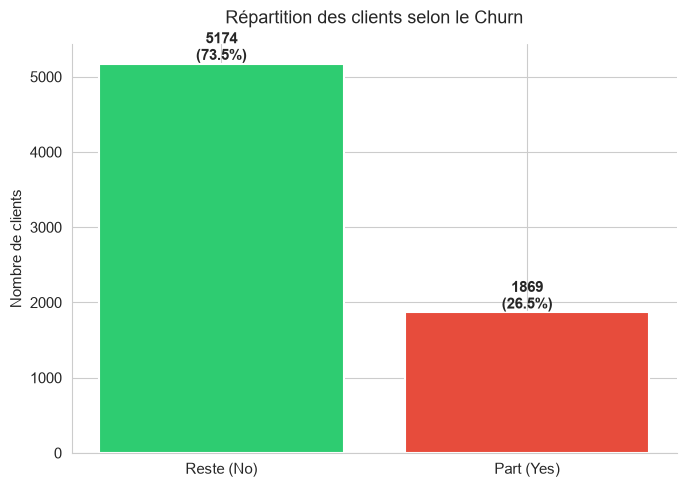

In [40]:
def plot_churn_distribution(df: pd.DataFrame):
    """Diagramme en barres de la répartition Churn Yes/No."""
    fig, ax = plt.subplots(figsize=(7, 5))
    churn_counts = df['Churn'].value_counts()
    bars = ax.bar(['Reste (No)', 'Part (Yes)'], churn_counts.values,
                   color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
    total = churn_counts.sum()
    for bar in bars:
        height = bar.get_height()
        pct = (height / total) * 100
        ax.text(bar.get_x() + bar.get_width()/2, height + 50, f'{height}\n({pct:.1f}%)',
                ha='center', fontsize=11, fontweight='bold')
    ax.set_title('Répartition des clients selon le Churn', pad=15)
    ax.set_ylabel('Nombre de clients')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_churn_distribution(df)

**Lecture** — Environ **26.5% des clients** ont résilié (`Churn = Yes`), contre 73.5% qui sont restés.

**Remarque** — Ce déséquilibre (~74/26) doit être pris en compte lors de la modélisation : un modèle naïf qui prédit toujours "reste" atteindrait ~74% d'accuracy sans rien apprendre. D'où l'usage de `class_weight='balanced'` et de métriques comme le F1-score/ROC-AUC plutôt que la seule accuracy (voir section modélisation).

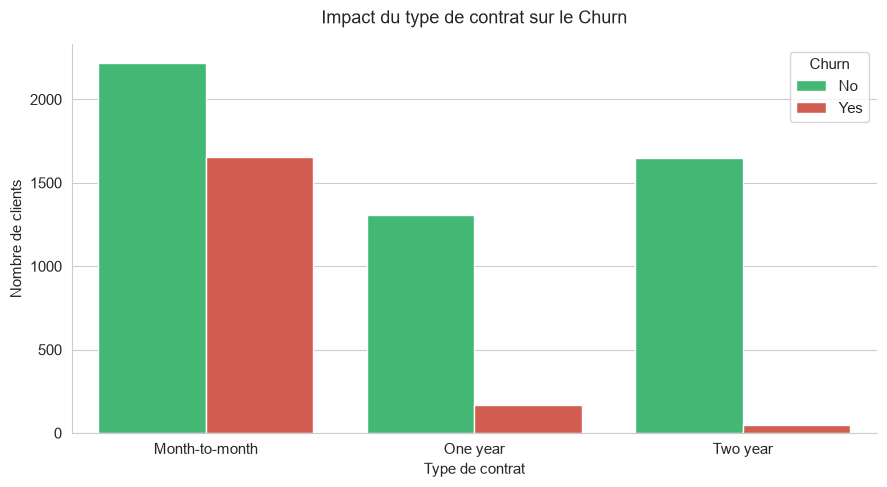

In [41]:
def plot_contract_churn(df: pd.DataFrame):
    """Countplot Contract vs Churn."""
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.countplot(data=df, x='Contract', hue='Churn', palette=['#2ecc71', '#e74c3c'], edgecolor='white', ax=ax)
    ax.set_title('Impact du type de contrat sur le Churn', pad=15)
    ax.set_xlabel('Type de contrat')
    ax.set_ylabel('Nombre de clients')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_contract_churn(df)

**Lecture** — Le contrat **mensuel (Month-to-month)** concentre la grande majorité des départs, avec un taux de churn d'environ **42%**, contre ~11% pour les contrats d'un an et moins de 3% pour les contrats de deux ans.

C'est le facteur de risque le plus fort du dataset : l'engagement contractuel retient fortement les clients.

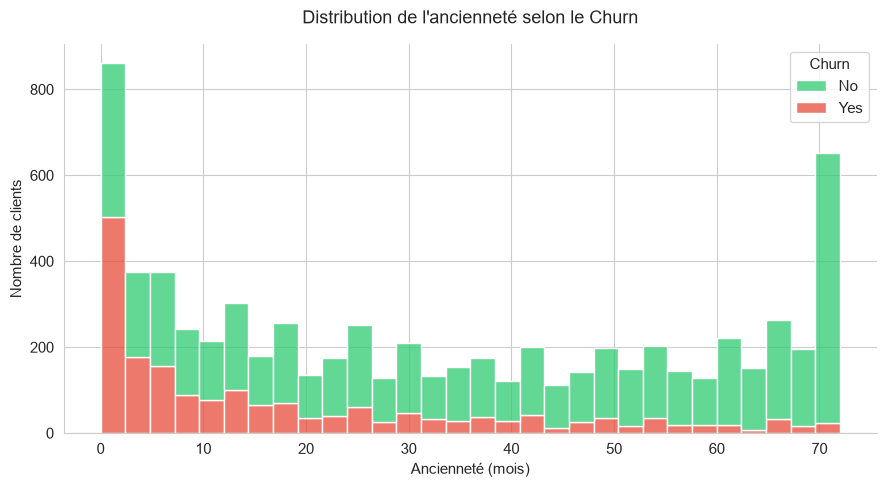

In [42]:
def plot_tenure_distribution(df: pd.DataFrame):
    """Histogramme empilé de l'ancienneté selon le Churn."""
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30,
                 palette=['#2ecc71', '#e74c3c'], edgecolor='white', ax=ax)
    ax.set_title("Distribution de l'ancienneté selon le Churn", pad=15)
    ax.set_xlabel('Ancienneté (mois)')
    ax.set_ylabel('Nombre de clients')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_tenure_distribution(df)

**Lecture** — Le churn est concentré sur les clients récents : le pic des départs se situe dans les premiers mois d'ancienneté, puis diminue progressivement. Les clients qui dépassent ~30 mois d'ancienneté partent très rarement — la fidélité se construit surtout dans la première année.

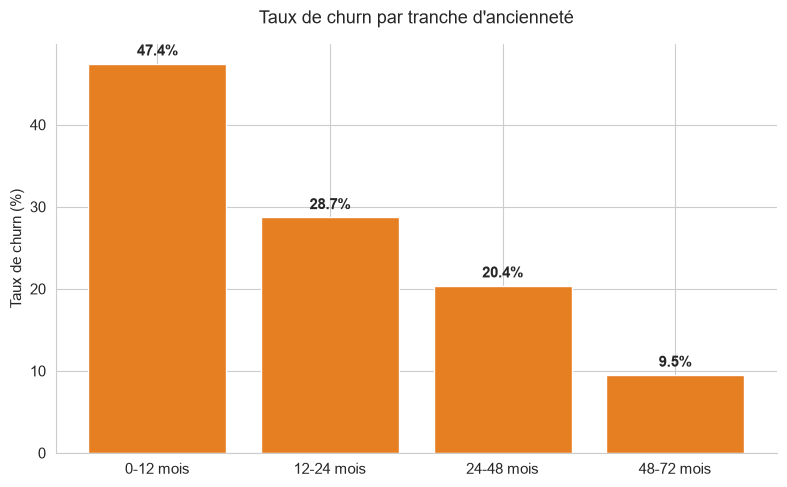

In [43]:
def plot_tenure_groups_churn_rate(df: pd.DataFrame):
    """Taux de churn par tranche d'ancienneté."""
    df2 = df.copy()
    churn_num = df2['Churn'] if df2['Churn'].dtype in ('int64', 'float64') \
        else df2['Churn'].map({'Yes': 1, 'No': 0})
    df2['Churn_num'] = churn_num

    bins = [0, 12, 24, 48, 72]
    labels = ['0-12 mois', '12-24 mois', '24-48 mois', '48-72 mois']
    df2['tenure_group'] = pd.cut(df2['tenure'], bins=bins, labels=labels, include_lowest=True)
    rates = df2.groupby('tenure_group', observed=True)['Churn_num'].mean() * 100

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(rates.index.astype(str), rates.values, color='#e67e22', edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.1f}%', ha='center', fontweight='bold')
    ax.set_title("Taux de churn par tranche d'ancienneté", pad=15)
    ax.set_ylabel('Taux de churn (%)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_tenure_groups_churn_rate(df)

**Lecture** — Ce graphique quantifie ce que montrait l'histogramme précédent : le taux de churn chute fortement après la première année (0-12 mois) et continue de baisser ensuite. La tranche 0-12 mois est celle où l'effort de rétention doit se concentrer en priorité.

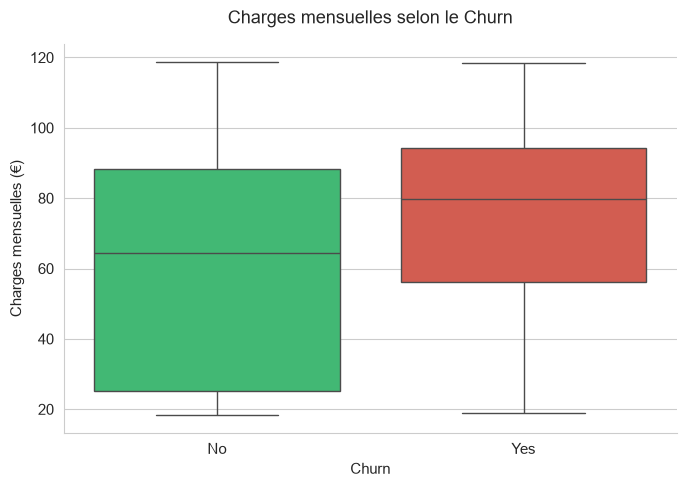

In [44]:
def plot_monthly_charges_boxplot(df: pd.DataFrame):
    """Boxplot des charges mensuelles selon le Churn."""
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn',
                palette=['#2ecc71', '#e74c3c'], legend=False, ax=ax)
    ax.set_title('Charges mensuelles selon le Churn', pad=15)
    ax.set_xlabel('Churn')
    ax.set_ylabel('Charges mensuelles (€)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_monthly_charges_boxplot(df)

**Lecture** — Les clients qui partent paient en moyenne des charges mensuelles **plus élevées** que ceux qui restent. Une facture mensuelle élevée semble donc associée à un risque de départ plus fort.

**Remarque de correction** — Le code original utilisait `sns.boxplot(..., palette=..., x='Churn')` sans `hue`, ce qui déclenche un `FutureWarning` (seaborn ≥ 0.13). Corrigé ici avec `hue='Churn'` + `legend=False`, qui donne le même rendu sans le warning.

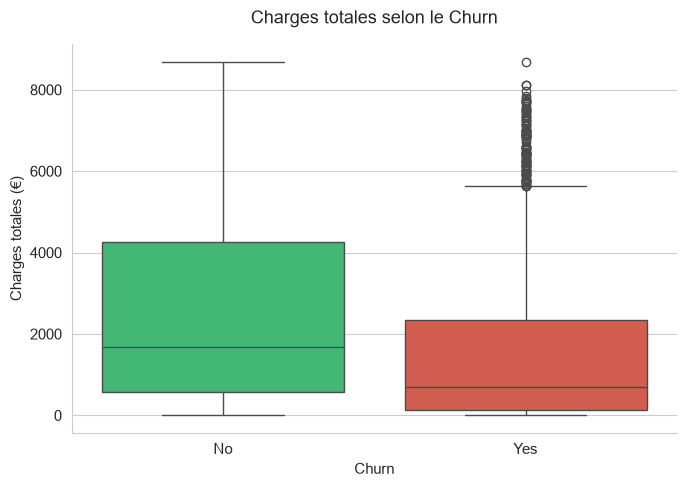

In [45]:
def plot_total_charges_boxplot(df: pd.DataFrame):
    """Boxplot des charges totales selon le Churn."""
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.boxplot(data=df, x='Churn', y='TotalCharges', hue='Churn',
                palette=['#2ecc71', '#e74c3c'], legend=False, ax=ax)
    ax.set_title('Charges totales selon le Churn', pad=15)
    ax.set_xlabel('Churn')
    ax.set_ylabel('Charges totales (€)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_total_charges_boxplot(df)

**Lecture** — À l'inverse de `MonthlyCharges`, les clients qui partent ont des charges **totales plus faibles**. Ce n'est pas contradictoire : `TotalCharges` dépend surtout de l'ancienneté (`tenure × MonthlyCharges` environ), et on a vu que les clients qui partent sont majoritairement des clients récents — ils n'ont simplement pas eu le temps d'accumuler des charges totales élevées.

Cette variable illustre bien pourquoi il faut toujours croiser les résultats avec le contexte : prise isolément, `TotalCharges` pourrait laisser penser à tort que "payer moins au total" pousse au départ.

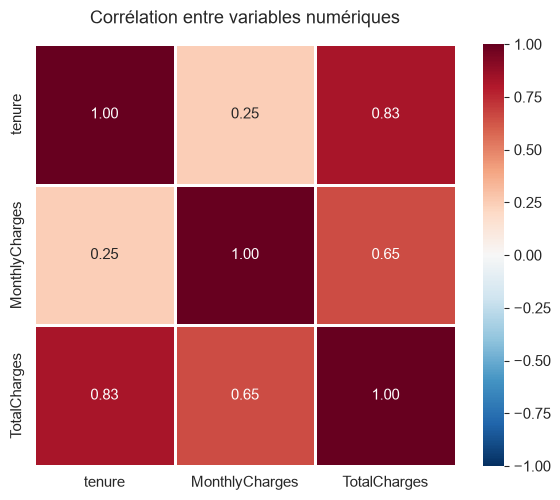

In [46]:
def plot_correlation_heatmap(df: pd.DataFrame):
    """Heatmap de corrélation entre variables numériques."""
    fig, ax = plt.subplots(figsize=(6, 5))
    corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
    sns.heatmap(corr, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, center=0,
                square=True, linewidths=1, fmt='.2f', ax=ax)
    ax.set_title('Corrélation entre variables numériques', pad=15)
    plt.tight_layout()
    plt.show()

plot_correlation_heatmap(df)

**Lecture** — Corrélation forte et logique entre `tenure` et `TotalCharges` (plus un client reste longtemps, plus il cumule de charges), et corrélation modérée entre `MonthlyCharges` et `TotalCharges`. `tenure` et `MonthlyCharges` sont quasiment indépendantes — l'ancienneté n'explique pas le niveau de facturation mensuelle.

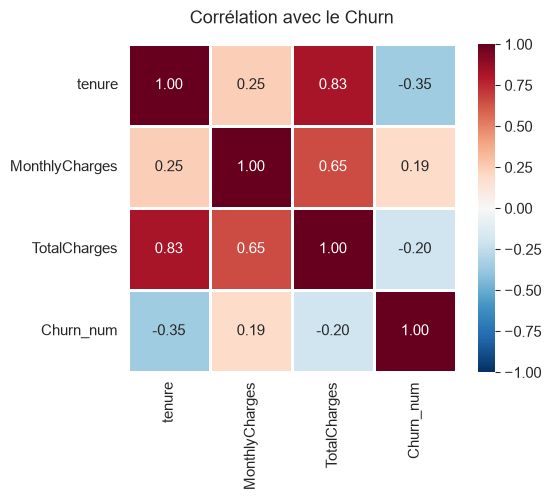

In [47]:
def plot_numeric_correlation_with_churn(df: pd.DataFrame):
    """Heatmap de corrélation incluant le Churn (encodé en 0/1)."""
    df2 = df.copy()
    df2['Churn_num'] = df2['Churn'] if df2['Churn'].dtype in ('int64', 'float64') \
        else df2['Churn'].map({'Yes': 1, 'No': 0})
    corr = df2[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']].corr()

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(corr, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, center=0,
                square=True, linewidths=1, fmt='.2f', ax=ax)
    ax.set_title('Corrélation avec le Churn', pad=15)
    plt.tight_layout()
    plt.show()

plot_numeric_correlation_with_churn(df)

**Lecture** — `tenure` a la corrélation **négative** la plus forte avec `Churn` (~ -0.35) : plus l'ancienneté augmente, moins le churn est probable — cohérent avec les graphiques précédents. `MonthlyCharges` a une corrélation **positive** modérée (~ +0.19) : payer plus cher augmente légèrement le risque de départ. `TotalCharges` a une corrélation négative, mais c'est un effet indirect de la corrélation avec `tenure`, pas une relation causale propre.

**Remarque** — La heatmap précédente ne montrait que les corrélations entre variables numériques *entre elles*, jamais avec la cible `Churn`. Cette version complète le diagnostic en identifiant directement quelle variable numérique est la plus prédictive.

## 5. Analyse exploratoire — Variables catégorielles et taux de churn

On utilise le **taux de churn (%)** plutôt que le comptage brut : un countplot montre le nombre de clients par catégorie, pas le risque. Le taux de churn est plus direct pour identifier les facteurs de risque.

In [48]:
def plot_churn_rate_by_category(df: pd.DataFrame, col: str, ax=None, title: str = None):
    """Affiche le taux de churn (%) par catégorie d'une variable donnée."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 5))

    churn_num = df['Churn'] if df['Churn'].dtype in ('int64', 'float64') else df['Churn'].map({'Yes': 1, 'No': 0})
    rates = df.assign(_c=churn_num).groupby(col)['_c'].mean().sort_values(ascending=False) * 100

    colors = plt.cm.RdYlGn_r(rates.values / 100)
    bars = ax.bar(rates.index.astype(str), rates.values, color=colors, edgecolor='white')
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=9, fontweight='bold')

    ax.set_title(title or f'Taux de churn par {col}', fontsize=11)
    ax.set_ylabel('Taux de churn (%)')
    ax.set_ylim(0, max(rates.values) * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.setp(ax.get_xticklabels(), rotation=25, ha='right')

    if standalone:
        plt.tight_layout()
        plt.show()


def plot_churn_rate_grid(df: pd.DataFrame, cols: list, ncols: int = 3, figsize_per_plot=(5, 4)):
    """Affiche le taux de churn pour plusieurs colonnes, en grille."""
    n = len(cols)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_plot[0]*ncols, figsize_per_plot[1]*nrows))
    axes = axes.flatten() if n > 1 else [axes]
    for ax, col in zip(axes, cols):
        plot_churn_rate_by_category(df, col, ax=ax)
    for ax in axes[n:]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

### 5.1 Profil démographique

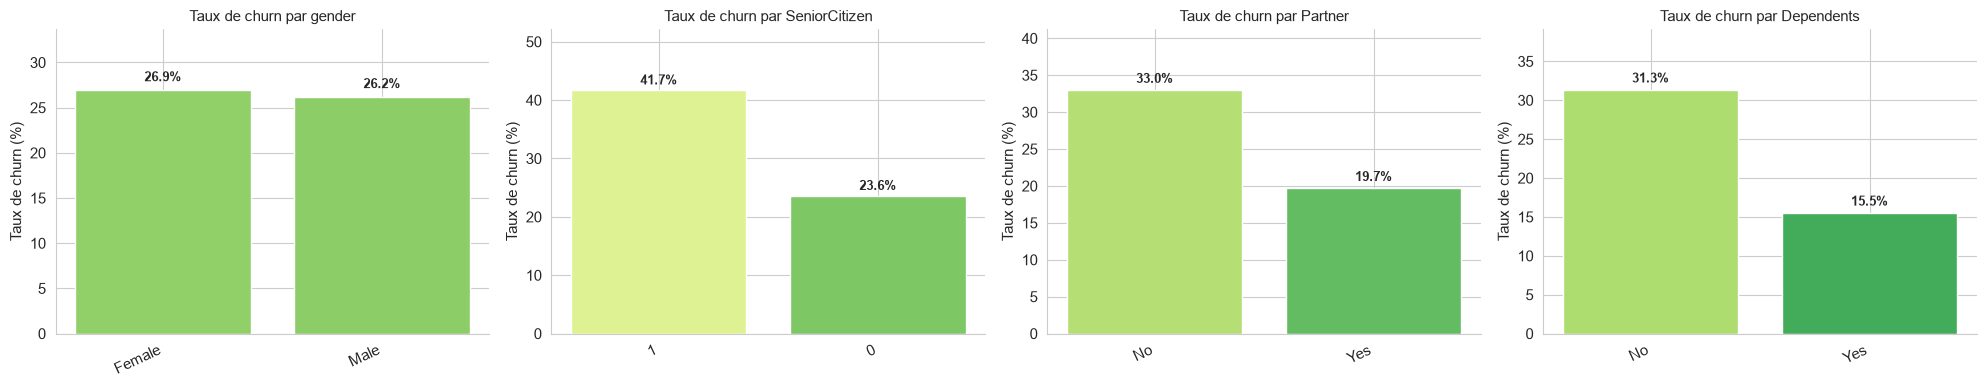

In [49]:
plot_churn_rate_grid(df, ['gender', 'SeniorCitizen', 'Partner', 'Dependents'], ncols=4)

**Lecture**
- **gender** : 26.9% (Femmes) vs 26.2% (Hommes) — aucune différence significative, le genre n'est pas un facteur de churn.
- **SeniorCitizen** : 41.7% (senior) vs 23.6% (non-senior) — les clients seniors churnent près de 2× plus.
- **Partner** : 33.0% (sans partenaire) vs 19.7% (avec partenaire) — les clients seuls sont beaucoup plus volatils.
- **Dependents** : 31.3% (sans personne à charge) vs 15.5% (avec) — même tendance, encore plus marquée.

**Conclusion** — Le profil du client fidèle type : en couple, avec des personnes à charge, foyer stable avec abonnement partagé. Le profil à risque : client isolé (senior seul, célibataire, sans enfants).

### 5.2 Services téléphoniques

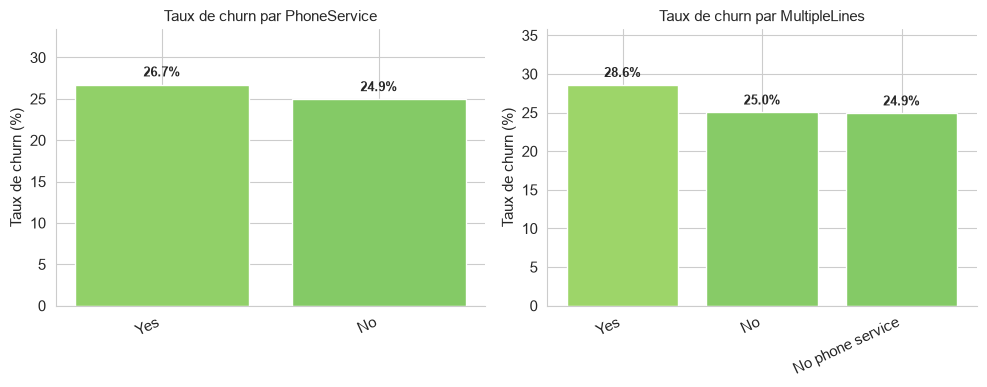

In [50]:
plot_churn_rate_grid(df, ['PhoneService', 'MultipleLines'], ncols=2)

**Lecture** — Le service téléphonique de base et le fait d'avoir plusieurs lignes n'ont qu'un impact limité sur le churn : ce ne sont pas des variables discriminantes majeures, contrairement aux services internet (voir ci-dessous).

### 5.3 Services internet

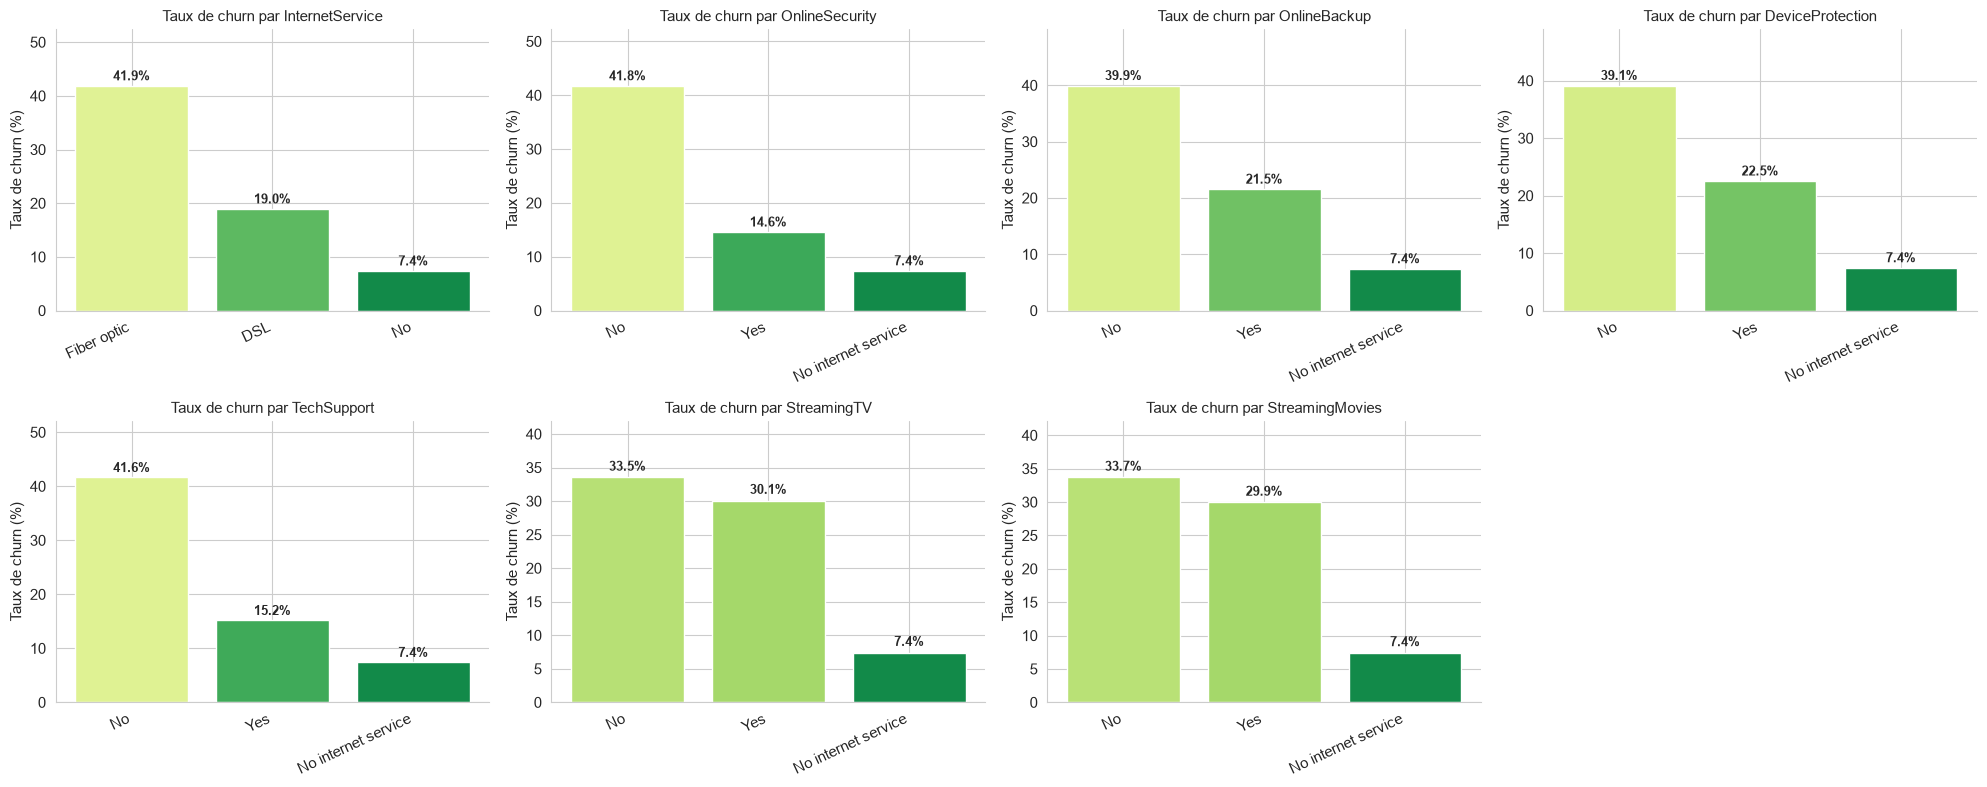

In [51]:
services = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
plot_churn_rate_grid(df, services, ncols=4)

**Lecture**
- **InternetService** : la Fibre optique (Fiber optic) a le taux de churn le plus élevé (~42%), largement au-dessus du DSL (~19%) et des clients sans internet (~7%) — contre-intuitif au premier abord (la fibre est un service premium), souvent lié à une insatisfaction sur le prix ou la qualité perçue du support pour ce service.
- **OnlineSecurity / TechSupport** : l'**absence** de ces services est associée à un churn nettement plus élevé — les clients sans support technique ou sans sécurité en ligne partent plus.
- **StreamingTV / StreamingMovies** : impact plus faible, ces services sont moins déterminants.

**Conclusion** — Les services d'assistance et de sécurité (support technique, sécurité en ligne) semblent jouer un rôle de rétention plus fort que les services de loisir (streaming).

### 5.4 Facturation et paiement

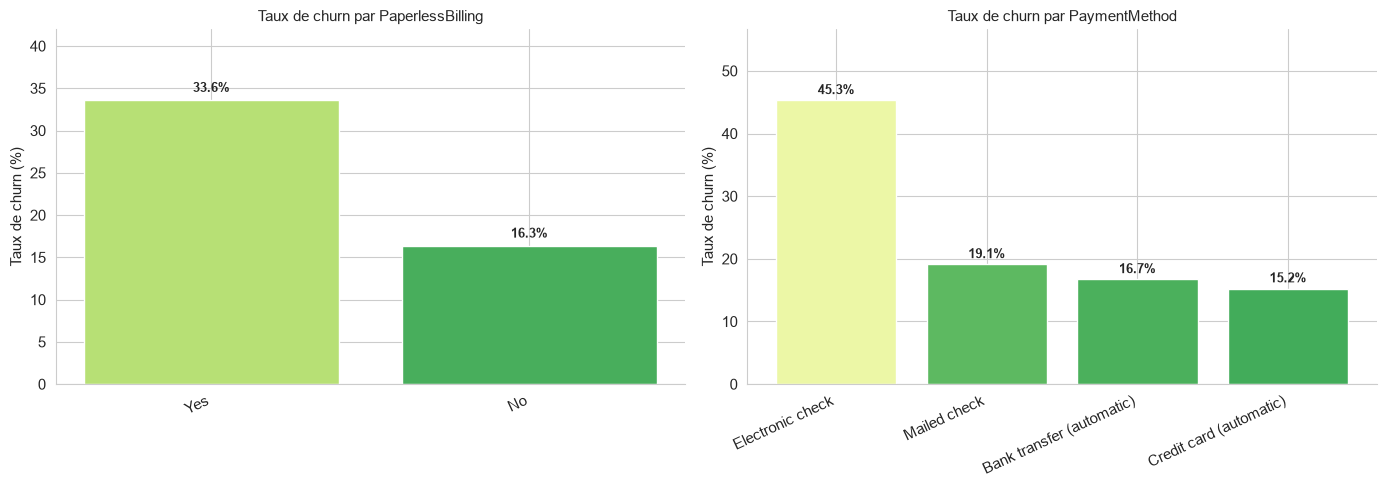

In [52]:
plot_churn_rate_grid(df, ['PaperlessBilling', 'PaymentMethod'], ncols=2, figsize_per_plot=(7, 5))

**Lecture**
- **PaperlessBilling** : les clients en facturation dématérialisée churnent davantage que ceux en facture papier.
- **PaymentMethod** : le **chèque électronique (Electronic check)** se distingue nettement avec le taux de churn le plus élevé (~45%), contre ~15-19% pour les paiements automatiques (carte bancaire, prélèvement).

**Conclusion** — Les moyens de paiement automatiques (moins de friction, pas d'action mensuelle requise) sont associés à une meilleure rétention. Le chèque électronique pourrait aussi être un indicateur indirect d'un profil client plus attentif à ses dépenses, donc plus enclin à comparer les offres concurrentes.

### 5.5 Relations entre variables numériques et Churn

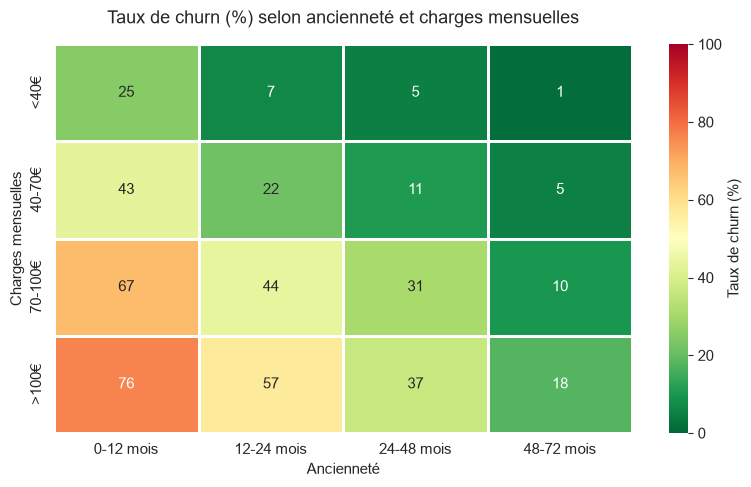

In [53]:
def plot_tenure_charges_heatmap(df: pd.DataFrame):
    """
    Heatmap simple : taux de churn (%) selon des tranches d'ancienneté
    et de charges mensuelles. Remplace le scatter (trop dense à lire
    avec des milliers de points superposés) par une vue croisée
    directement lisible.
    """
    df2 = df.copy()
    churn_num = df2['Churn'] if df2['Churn'].dtype in ('int64', 'float64') \
        else df2['Churn'].map({'Yes': 1, 'No': 0})
    df2['Churn_num'] = churn_num

    tenure_bins = [0, 12, 24, 48, 72]
    tenure_labels = ['0-12 mois', '12-24 mois', '24-48 mois', '48-72 mois']
    charges_bins = [0, 40, 70, 100, 150]
    charges_labels = ['<40€', '40-70€', '70-100€', '>100€']

    df2['tenure_group'] = pd.cut(df2['tenure'], bins=tenure_bins, labels=tenure_labels, include_lowest=True)
    df2['charges_group'] = pd.cut(df2['MonthlyCharges'], bins=charges_bins, labels=charges_labels, include_lowest=True)

    pivot = df2.pivot_table(values='Churn_num', index='charges_group', columns='tenure_group',
                             aggfunc='mean', observed=True) * 100

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r', vmin=0, vmax=100,
                cbar_kws={'label': 'Taux de churn (%)'}, linewidths=1, linecolor='white', ax=ax)
    ax.set_title('Taux de churn (%) selon ancienneté et charges mensuelles', pad=15)
    ax.set_xlabel('Ancienneté')
    ax.set_ylabel('Charges mensuelles')
    plt.tight_layout()
    plt.show()

plot_tenure_charges_heatmap(df)

**Lecture** — La zone à risque la plus dense (points rouges) se situe en bas à gauche : **faible ancienneté + charges mensuelles élevées**. C'est la combinaison la plus dangereuse — un nouveau client avec une facture élevée est celui qu'il faut surveiller en priorité.

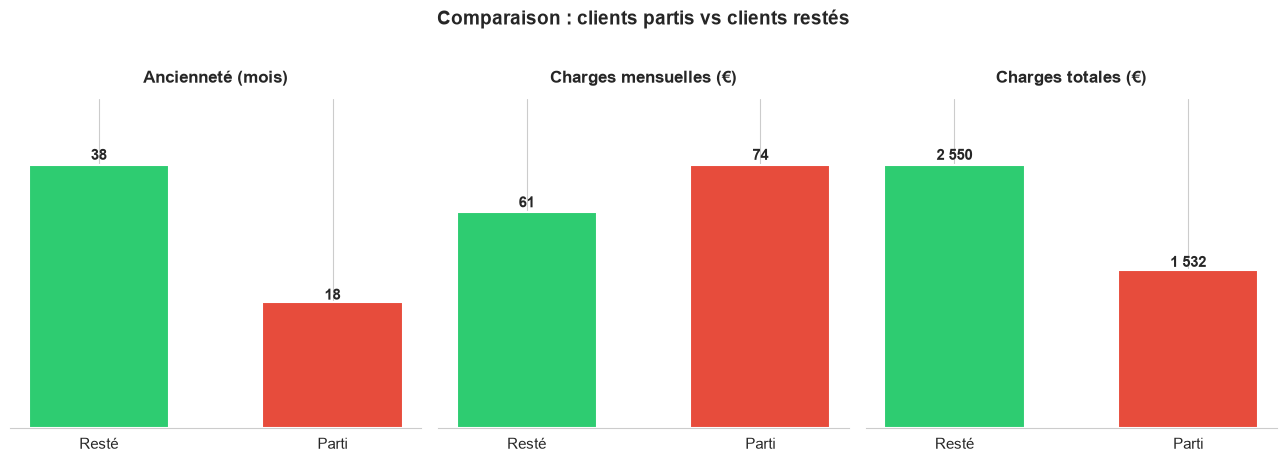

In [54]:
def compare_numeric_by_churn_chart(df: pd.DataFrame):
    """
    Comparaison visuelle simple : 3 mini-graphiques en barres, un par variable,
    opposant directement les clients partis vs restés.
    """
    df2 = df.copy()

    # Détecte si Churn est encore en 'Yes'/'No' ou déjà en 0/1
    if df2['Churn'].dtype == 'object' or str(df2['Churn'].dtype) == 'str':
        label_reste, label_parti = 'No', 'Yes'
    else:
        label_reste, label_parti = 0, 1

    summary = df2.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()

    variables = [
        ('tenure', 'Ancienneté (mois)'),
        ('MonthlyCharges', 'Charges mensuelles (€)'),
        ('TotalCharges', 'Charges totales (€)'),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

    for ax, (col, label) in zip(axes, variables):
        values = [summary.loc[label_reste, col], summary.loc[label_parti, col]]
        colors = ['#2ecc71', '#e74c3c']
        bars = ax.bar(['Resté', 'Parti'], values, color=colors, edgecolor='white', linewidth=1.5, width=0.6)

        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
                    f'{val:,.0f}'.replace(',', ' '), ha='center', fontweight='bold', fontsize=11)

        ax.set_title(label, fontsize=12, fontweight='bold', pad=12)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.set_yticks([])
        ax.set_ylim(0, max(values) * 1.25)

    fig.suptitle('Comparaison : clients partis vs clients restés', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

compare_numeric_by_churn_chart(df)

**Lecture** — Vue d'ensemble confirmant les tendances déjà identifiées : les clients qui partent (rouge) se concentrent sur les faibles anciennetés, avec une légère tendance à des charges mensuelles plus hautes. Pas de nouvelle relation cachée entre variables numériques prises deux à deux au-delà de ce qui a déjà été observé.

### 5.6 Tableau récapitulatif des facteurs de risque

In [55]:
def summarize_churn_rates(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Pour chaque variable, identifie la catégorie la plus à risque et la plus sûre."""
    churn_num = df['Churn'] if df['Churn'].dtype in ('int64', 'float64') else df['Churn'].map({'Yes': 1, 'No': 0})
    df = df.assign(_c=churn_num)
    rows = []
    for col in cols:
        rates = df.groupby(col)['_c'].mean() * 100
        rows.append({
            'variable': col,
            'categorie_a_risque': rates.idxmax(), 'taux_max (%)': round(rates.max(), 1),
            'categorie_plus_sure': rates.idxmin(), 'taux_min (%)': round(rates.min(), 1),
            'ecart (%)': round(rates.max() - rates.min(), 1),
        })
    return pd.DataFrame(rows).sort_values('ecart (%)', ascending=False).reset_index(drop=True)

all_cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
summarize_churn_rates(df, all_cat_cols)

,variable,categorie_a_risque,taux_max (%),categorie_plus_sure,taux_min (%),ecart (%)
0,Contract,Month-to-month,42.7,Two year,2.8,39.9
1,InternetService,Fiber optic,41.9,No,7.4,34.5
2,OnlineSecurity,No,41.8,No internet service,7.4,34.4
3,TechSupport,No,41.6,No internet service,7.4,34.2
4,OnlineBackup,No,39.9,No internet service,7.4,32.5
5,DeviceProtection,No,39.1,No internet service,7.4,31.7
6,PaymentMethod,Electronic check,45.3,Credit card (automatic),15.2,30.0
7,StreamingMovies,No,33.7,No internet service,7.4,26.3
8,StreamingTV,No,33.5,No internet service,7.4,26.1
9,SeniorCitizen,1,41.7,0,23.6,18.1


**Lecture** — Le tableau, trié par écart décroissant, classe objectivement les variables les plus discriminantes. `Contract` arrive généralement en tête (écart de ~40 points entre mensuel et 2 ans), suivi de `InternetService` (Fibre vs pas d'internet) et `TechSupport`/`OnlineSecurity`.

**Remarque** — Ce classement est purement descriptif (analyse univariée) : il ne tient pas compte des interactions entre variables. Un modèle de Machine Learning (Random Forest, régression logistique) permettra d'aller plus loin en mesurant l'importance de chaque variable *toutes choses égales par ailleurs*.

## 6. Encodage des variables

Les modèles de Machine Learning ne comprennent que des nombres. On encode donc :
- **Churn** : `Yes`/`No` → `1`/`0`
- **Variables catégorielles** (Contract, PaymentMethod, etc.) → one-hot encoding

In [56]:
def encode_target_and_drop_id(df: pd.DataFrame) -> pd.DataFrame:
    """Encode Churn en 0/1 et supprime customerID (non-informatif pour le modèle)."""
    df = df.copy()
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
    df = df.drop(columns=['customerID'])
    return df

In [57]:
def encode_categorical(df: pd.DataFrame) -> pd.DataFrame:
    """One-hot encode les colonnes catégorielles (drop_first=True évite la colinéarité)."""
    categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    # Convertit les colonnes booléennes (True/False) en 0/1 pour plus de clarté
    bool_cols = df_encoded.select_dtypes(include='bool').columns
    df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

    print(f"Forme avant encodage : {df.shape}")
    print(f"Forme après encodage : {df_encoded.shape}")
    return df_encoded

In [58]:
df = encode_target_and_drop_id(df)
df_encoded = encode_categorical(df)
df_encoded.head()

Forme avant encodage : (7043, 20)
Forme après encodage : (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


**Lecture** — Le dataset passe de 20 à 30 colonnes environ : chaque variable catégorielle à N catégories éclate en (N-1) colonnes binaires (`drop_first=True` retire une catégorie de référence pour éviter la redondance/colinéarité).

**Remarque de correction** — `pd.get_dummies()` génère des colonnes de type `bool` (`True`/`False`) dans les versions récentes de pandas. On les convertit explicitement en `int` (`0`/`1`) pour un CSV plus lisible ; le comportement pour un modèle est identique dans les deux cas.

## 7. Séparation train/test et standardisation

**Pourquoi séparer train et test ?** Si on entraîne et évalue un modèle sur les mêmes données, il peut sembler excellent en ayant simplement "mémorisé" les exemples, sans être capable de généraliser à de nouveaux clients. Le test set (jamais vu pendant l'entraînement) donne une estimation honnête de la performance réelle.

**Pourquoi standardiser après le split, pas avant ?** Standardiser sur tout le dataset avant le split ferait "fuiter" une information du test set (sa moyenne, son écart-type) dans l'entraînement — une fuite de données (*data leakage*) qui biaise l'évaluation.

In [59]:
def split_and_scale(df_encoded: pd.DataFrame, target_col: str = 'Churn',
                     test_size: float = 0.2, random_state: int = 42):
    """
    Sépare train/test PUIS standardise, en ajustant le scaler
    uniquement sur le train (pas de fuite de données).
    """
    num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

    X = df_encoded.drop(columns=[target_col])
    y = df_encoded[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    scaler = StandardScaler()
    X_train, X_test = X_train.copy(), X_test.copy()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])  # transform seul, pas fit

    return X_train, X_test, y_train, y_test, scaler

In [60]:
X_train, X_test, y_train, y_test, scaler = split_and_scale(df_encoded)
print(f"Train : {X_train.shape[0]} clients | Test : {X_test.shape[0]} clients")
X_train.head()

Train : 5634 clients | Test : 1409 clients


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0,0.102371,-0.521976,-0.262257,1,0,0,0,1,0,...,0,1,0,1,0,0,0,0,1,0
3151,0,-0.711743,0.337478,-0.503635,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
4860,0,-0.793155,-0.809013,-0.749883,1,1,1,0,1,0,...,0,0,0,0,0,1,0,0,0,1
3867,0,-0.263980,0.284384,-0.172722,0,1,0,1,0,0,...,0,1,0,1,0,1,1,1,0,0
3810,0,-1.281624,-0.676279,-0.989374,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,1,0


**Lecture** — Le split `stratify=y` garantit que la proportion de churn (~26.5%) est identique dans le train et le test — indispensable vu le déséquilibre des classes, sinon un split aléatoire pourrait produire un test set avec une proportion de churn très différente du train, faussant l'évaluation.

**Remarque de correction** — Dans la version originale, `StandardScaler` était ajusté (`fit_transform`) sur l'intégralité du dataset avant tout split. C'est la correction la plus importante apportée à ce pipeline : elle évite que le modèle bénéficie indirectement d'informations du test set.

## 8. Sauvegarde des jeux de données

In [61]:
def save_dataset(df: pd.DataFrame, path: str):
    """Sauvegarde un dataframe au format CSV."""
    df.to_csv(path, index=False)
    print(f"Dataset sauvegardé avec succès : {path}")

In [62]:
train_df = X_train.copy()
train_df['Churn'] = y_train
test_df = X_test.copy()
test_df['Churn'] = y_test

save_dataset(train_df, '../Data/processed/telco_churn_train.csv')
save_dataset(test_df, '../Data/processed/telco_churn_test.csv')

Dataset sauvegardé avec succès : ../Data/processed/telco_churn_train.csv
Dataset sauvegardé avec succès : ../Data/processed/telco_churn_test.csv


**Remarque** — On sauvegarde deux fichiers séparés (`train`/`test`) plutôt qu'un seul CSV global déjà standardisé sur toutes les données, cohérent avec la correction de fuite de données faite plus haut : le split doit rester visible et respecté dans les fichiers produits, pas recombiné après coup.

## Résumé général

**Facteurs de risque de churn identifiés (du plus fort au plus faible)**
1. **Type de contrat** — mensuel = risque très élevé, engagement long = fidélisant
2. **Ancienneté** — le risque est concentré sur les 12 premiers mois
3. **Service internet** — la Fibre optique churn plus que le DSL
4. **Absence de support/sécurité** — pas de TechSupport ni d'OnlineSecurity = risque accru
5. **Profil isolé** — senior, sans partenaire, sans personne à charge
6. **Mode de paiement** — chèque électronique = risque élevé ; paiement automatique = fidélisant
7. **Charges mensuelles élevées** — effet positif mais plus modéré sur le churn

**Corrections techniques apportées au pipeline original**
- Fuite de données corrigée : standardisation après le split, pas avant
- Warnings pandas/seaborn corrigés (`select_dtypes`, `boxplot` avec `hue`)
- Cellules dupliquées supprimées
- Vérifications de qualité ajoutées (types, cohérence logique, outliers)
- Conversion des colonnes booléennes en 0/1 après l'encodage pour la lisibilité
